# Machine Translation & Document Search
© Made by Joris Heemskerk, all rights reserved.

This notebook contains all deliverables for FA4: Machine Translation & Document Search.

In [1]:
import numpy as np
import pandas as pd
import re
import string 
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Annotated
from tqdm import tqdm
from nltk.corpus import twitter_samples, stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import PorterStemmer
from operator import itemgetter
np.random.seed(0)

## Part I: Machine Translataion
In the first part we will try to implement a simple machine translation system to translate English to words to French

### Step 1: Loading in the data

We were provided with 4 files:
- ***en_embeddings.p***\
A dictionary of 6370 English words and their embeddings (vector of 300 floats).
- ***fr_embeddings.p***\
A dictionary of 5766 French words and their embeddings (vector of 300 floats).
- ***en_fr.train.txt***\
A dataframe of 10872 English words with their French counterparts.\
NOTE: Some words have multiple translations and therefore may appear more than once.
- ***en_fr.test.txt***\
A dataframe of 2943 English words with their French counterparts.\
NOTE: Some words have multiple translations and therefore may appear more than once.

Lets load all of these files into variables. To show that this works, I will print the first couple of items of each container.

In [2]:
en_fr_train = pd.read_csv("en-fr.train.txt", sep=' ', header=None, names=["en", "fr"])
en_fr_train.head()

,en,fr
0,the,le
1,the,les
2,the,la
3,and,et
4,was,fut


In [3]:
en_fr_test = pd.read_csv("en-fr.test.txt", sep=' ', header=None, names=["en", "fr"])
en_fr_test.head()

,en,fr
0,torpedo,torpille
1,torpedo,torpilles
2,giovanni,giovanni
3,chat,discuter
4,chat,discussion


In [4]:
fr_embeddings = pd.read_pickle('fr_embeddings.p')
list(fr_embeddings.items())[:3]

[('la',
  array([-6.18250e-03, -9.43867e-04, -8.82648e-03,  3.24623e-02,
         -2.18281e-02,  2.98912e-02,  2.29990e-02,  2.80628e-02,
          5.87757e-03, -2.56806e-02,  4.21732e-02, -9.37519e-03,
          2.86577e-02, -5.08309e-02, -7.13388e-02, -8.34270e-03,
         -2.88709e-02, -3.85773e-02,  4.38649e-02,  1.18239e-01,
         -8.57782e-02,  2.65617e-02, -1.21373e-01, -1.88254e-02,
         -5.46811e-02, -8.06788e-02,  3.16896e-02, -3.78146e-02,
          4.16330e-02, -3.09924e-02, -4.15530e-02,  5.95500e-02,
         -6.08129e-02,  1.29453e-01,  5.98485e-02, -1.22053e-01,
         -4.65893e-02, -1.76105e-02,  8.36952e-02, -3.43169e-02,
          1.02949e-02, -3.74583e-02,  1.56218e-02,  2.52615e-02,
          3.09000e-02, -6.15672e-03,  1.78421e-02, -7.97611e-03,
          4.08416e-02, -3.61498e-02,  5.93975e-02, -6.13706e-02,
          2.76527e-02, -4.04968e-02,  4.02123e-02,  4.60480e-02,
          3.12373e-02,  4.31485e-02,  4.45423e-03,  9.88624e-05,
         -3.46425

In [5]:
en_embeddings = pd.read_pickle('en_embeddings.p')
list(en_embeddings.items())[:3]

[('the',
  array([ 0.08007812,  0.10498047,  0.04980469,  0.0534668 , -0.06738281,
         -0.12060547,  0.03515625, -0.11865234,  0.04394531,  0.03015137,
         -0.05688477, -0.07617188,  0.01287842,  0.04980469, -0.08496094,
         -0.06347656,  0.00628662, -0.04321289,  0.02026367,  0.01330566,
         -0.01953125,  0.09277344, -0.171875  , -0.00131989,  0.06542969,
          0.05834961, -0.08251953,  0.0859375 , -0.00318909,  0.05859375,
         -0.03491211, -0.0123291 , -0.0480957 , -0.00302124,  0.05639648,
          0.01495361, -0.07226562, -0.05224609,  0.09667969,  0.04296875,
         -0.03540039, -0.07324219,  0.03271484, -0.06176758,  0.00787354,
          0.0035553 , -0.00878906,  0.0390625 ,  0.03833008,  0.04443359,
          0.06982422,  0.01263428, -0.00445557, -0.03320312, -0.04272461,
          0.09765625, -0.02160645, -0.0378418 ,  0.01190186, -0.01391602,
         -0.11328125,  0.09326172, -0.03930664, -0.11621094,  0.02331543,
         -0.01599121,  0.0263

Now lets check that there are indeed enough items and that none of the data has gone missing.

In [6]:
print(f"The 'en_fr_train' dataset should have shape (10872,2). The actual shape is: {en_fr_train.shape}.") 
print(f"The 'en_fr_test' dataset should have shape (2943,2). The actual shape is: {en_fr_test.shape}.") 

The 'en_fr_train' dataset should have shape (10872,2). The actual shape is: (10872, 2).
The 'en_fr_test' dataset should have shape (2943,2). The actual shape is: (2943, 2).


The code below is copy and pasted from my FA3. If it were marked wrong in FA3, I would hate for the code below to receive me the same punishment, provided I did not get feedback on FA3 in time before the deadline of FA4.

In [7]:
print(f"There are {len(en_embeddings)}/6370 English embeddings present.\n")

print(f"The first embedding has {len(list(en_embeddings.values())[0])}/300 values.")

# The line below just counts the amount of lines that have the same amount of values as the first embedding.
correct_lengths = sum([True if len(value) == len(list(en_embeddings.values())[0]) else False for value in list(en_embeddings.values())])

# Line below cannot be in f-string due to '\'
check = '\033[92mtrue\033[00m' if correct_lengths == len(en_embeddings) else '\033[91mfalse\033[00m'
print(f"This rings {check} for all of the other English embeddings.")

There are 6370/6370 English embeddings present.

The first embedding has 300/300 values.
This rings true for all of the other English embeddings.


In [8]:
print(f"There are {len(fr_embeddings)}/5766 French embeddings present.\n")

print(f"The first embedding has {len(list(fr_embeddings.values())[0])}/300 values.")

# The line below just counts the amount of lines that have the same amount of values as the first embedding.
correct_lengths = sum([True if len(value) == len(list(fr_embeddings.values())[0]) else False for value in list(fr_embeddings.values())])

# Line below cannot be in f-string due to '\'
check = '\033[92mtrue\033[00m' if correct_lengths == len(fr_embeddings) else '\033[91mfalse\033[00m'
print(f"This rings {check} for all of the other French embeddings.")

There are 5766/5766 French embeddings present.

The first embedding has 300/300 values.
This rings true for all of the other French embeddings.


If everything seems to be in order (which it does) we can continue!

### Step 2: Creating the necessary matrices

Now that we have all of the data, we will need the following two matrices:
- ***X***\
This matrix contains embeddings for all English words in the training dataset, whose French translation also has an embedding.
- ***Y***\
This matrix contains embeddings for all French translations corresponding by index with `X`.

**NOTE**: This means that certain embeddings can appear twice in the data if any word has multiple translations.

In [9]:
X, Y = [], []

# Loop through the training data and try to append embeddings to both `X` and `Y`.
for _, row in en_fr_train.iterrows():
    try:
       en_embedding, fr_embedding = en_embeddings[row["en"]], fr_embeddings[row["fr"]]
       X.append(np.array(en_embedding))
       Y.append(np.array(fr_embedding))
    except KeyError:
        # Word not in one or both embeddings.
        continue

# Could not declare X and Y to be numpy arrays from the start, as their shapes are unknown.
X = np.array(X)
Y = np.array(Y)

Now lets see what we're left with:

In [10]:
f"{X.shape = }    {Y.shape = }"

'X.shape = (5717, 300)    Y.shape = (5717, 300)'

Not too shabby! At most we could have had about 5766 embeddings, as this is the maximum amount of French words we have embeddings for. This could be a tad higher, as we might have some French words that actually have multiple English translations. The amount of these is unknown to me as, to be honest, I could not really care less. 

### Step 3: Gradient Descent

We can now make the Gradient Descent algorithm that allows us to create a matrix of weights.\
This matrix can then be used to translate a new English word with, using its embeddings.

The algorithm is explained in further detail in the docstring of `grad_desc()`.

In [11]:
@dataclass
class GreaterThanEqual:
    """
    Used in Annotated types to define a minimum value for a parameter.
    This can be used to, for example, define unsigned integers.

    (Inspiration from https://stackoverflow.com/questions/65385585/where-are-the-type-annotation-constraints-valuerange-minlen-etc-in-python
     and https://peps.python.org/pep-0593/)

    + min (float) minimum value for a given parameter if used in Annotated.
    """
    min: float

def grad_desc(X: np.ndarray, Y: np.ndarray, num_iters: Annotated[int, GreaterThanEqual(0)], learning_rate: float=1)-> tuple[np.ndarray, float]:
    """
    Calculates a matrix of weights that can be used to predict translations.
    
    The function does this, using a Gradient Descent algorithm. Which works as follows:\n
    - Create a empty matrix (`R`) of size (`n`, `n`) (`n` is the second dimension of both `X` and `Y`).\n
      This matrix will store the weights.
    - For each requested iteration as defined by `num_iters`:\n
        * Calculate the gradient of the loss using the following formula:\n
          2/`m` * `X`.T •(`X` • `R` - `Y`)\n
          Where `m` is the first dimension of both `X` and `Y`)
        * Update `R` by subtracting the gradient times the provided `learning_rate`.
    - Return the resulting `R`, along with the loss as defined by:\n
      1/`m` * Σ`m`(i=1) Σ`n`(j=1) ((`X` • `R` - `Y`)ij)^2

    :param X: (np.ndarray) matrix of embeddings with shape (`m`,`n`)
    :param Y: (np.ndarray) Matrix of embeddings with shape (`m`,`n`). Each of which corresponds by index as a translation of `X`.
    :param num_iters: (Annotated[int, GreaterThanEqual(0)) number of times the gradient descent should examine all data points
    :param learning_rate: (float) Multiplier with which to weigh the gradient. DEFAULT = 1.

    :return: (np.ndarray) matrix of shape (`n`, `n`) with the (updated) weights
    :return: (float) loss at the end of training.
    """    
    m, n = X.shape
    R = np.zeros((n,n))
    for _ in range(num_iters):
        gradient = 2/m * np.dot(X.T, np.dot(X, R) - Y)
        R -= gradient * learning_rate
    return R, 1/m * ((np.dot(X, R) - Y)**2).sum()


Easy as pie. Now we can run it with the required `400` iterations with a learning rate of `.8`.

Before that, however, lets first print the starting loss by running `0` iterations.

In [12]:
weights, loss = grad_desc(X, Y, 0, .8)
f"{weights.shape = },    {loss = }"

'weights.shape = (300, 300),    loss = 1.00000000750199'

The starting loss seems to be `1`. Now lets train those `400` iterations.

In [13]:
weights, loss = grad_desc(X, Y, 400, .8)
f"{weights.shape = },    {loss = }"

'weights.shape = (300, 300),    loss = 0.5679545598321855'

Cool, `.57` is a steady improvement. It might not be great, but its at least improving.

### Step 4: Using `R` to make predictions

Now that we have these weights, we can use them to translate embeddings of new English words. 

To do so, we first need to redefine the `cosine_similarity()` from FA3.

In [14]:
@dataclass
class Range:
    """
    Used in Annotated types to define a range for a parameter.
    This can be used to, for example, define a cosine similarity that always outputs between -1 and 1.

    (Inspiration from https://stackoverflow.com/questions/65385585/where-are-the-type-annotation-constraints-valuerange-minlen-etc-in-python
     and https://peps.python.org/pep-0593/)

    + min (float) minimum value for a given parameter if used in Annotated.  INCLUSIVE
    + max (float) maximum value for a given parameter if used in Annotated.  INCLUSIVE
    """
    min: float
    max: float

def cosine_similarity(A: np.ndarray, B: np.ndarray)-> Annotated[float, range(-1, 1)]: # NOTE: Again, whats with the terrible variable names?
    """
    Calculates the cosine similarity between two vectors.

    :Rant:
    Please do not use this function, the same functionality is supported in `scipy`. Why am I even required to program this?
    Like honestly, all of the math is already written out in the assignment. 
    All I need to do is just look up how to do a `np.linalg.norm()` and plop down the formula. 
    I do not feel like I've gained any knowledge (except for the cool Annotated package; I absolutely love it).

    :param A: (np.ndarray) first vector
    :param B: (np.ndarray) second vector
    NOTE: Both vectors need to be of the exact same size

    :return: (Annotated[float, range(-1, 1)]) cosine similarity between `A` and `B`
    """
    return np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))

Done. Now lets create the prediction function that translates a given English word, finds its embedding, translates it, and finds the French word that is the nearest.

This is kind of like k-Nearest Neighbors, as we can return the `k` nearest words.


I decided to split the functionality between finding the `k` nearest words by index, and by actual words. This gives us the possibility to never work with strings and just use indices. This could be preferable in situations of large datasets that need predicting.

In [15]:
def predict_indices(english_word: str, R: np.ndarray, english_embeddings: dict[str, np.ndarray], french_embeddings: dict[str, np.ndarray], k: Annotated[int, GreaterThanEqual(1)]=1)-> np.ndarray:
    """
    For a given English word, try to find the `k` most likely French translations.

    This function does so using the following steps:
    - Try to get the embedding of the provided `english_word`. Throw funny error if this word does not have an embedding in the provided `english_embeddings`.
    - Calculate the dot product of this embedding with weight matrix `R`.
    - Find the index of the `k` nearest french words using the cosine similarity.
    - Return these `k` indices.

    :param english_word: (string) English word to translate
    :param R: (np.ndarray) weight matrix
    :param english_embeddings: (dict[str, np.ndarray]) embeddings for English words
    :param french_embeddings: (dict[str, np.ndarray]) embeddings for French words

    :return: (np.ndarray) `k` indices that correspond to french words in `french_embeddings`
    """
    try:
        res = np.dot(english_embeddings[english_word], R)
    except KeyError:
        raise KeyError(f"You dumb fuck; {english_word} is not in your provided embeddings!")
    
    return np.argsort(np.array([cosine_similarity(res, row) for row in french_embeddings.values()]))[-k:]

In [16]:
def predict_words(english_word: str, R: np.ndarray, english_embeddings: dict[str, np.ndarray], french_embeddings: dict[str, np.ndarray], k: Annotated[int, GreaterThanEqual(1)]=1)-> list[str]:
    """
    Based on indices as provided by `predict_indices()`, find the corresponding words in `french_embeddings`.

    :param english_word: (string) English word to translate
    :param R: (np.ndarray) weight matrix
    :param english_embeddings: (dict[str, np.ndarray]) embeddings for English words
    :param french_embeddings: (dict[str, np.ndarray]) embeddings for French words

    :return: (list[str]) `k` possible translations for `english_word` in order of likeliness.
    """
    
    indices = predict_indices(english_word, R, english_embeddings, french_embeddings, k)
    french_words_by_index = list(fr_embeddings.keys())
    french_words = []
    for i in indices:
        french_words.append(french_words_by_index[i])
        
    return french_words

Now lets try to get that >55% accuracy!

To do this, I will try to predict the words in the test set. I will only try to predict each unique English word, as this would just keep on giving me the same translations, messing with the percentages.\
Each prediction will be checked against all valid French translations for the given English word.

For example, if the data looked like this:
```
cheese fromages
cheese fromage
```
The code below would only try to predict "cheese" once. Both "fromages" and "fromage" would count as correct output.

The prediction will be counted as correct if one of the `k` predicted words is one of the valid French translations.

In [17]:
k=3

correct = 0
error_words = 0
unique_english_test_words = en_fr_test["en"].unique()
for english_word in tqdm(unique_english_test_words):
    try:
        predictions = predict_words(english_word, weights, en_embeddings, fr_embeddings, k)
        valid_translations = list(en_fr_test[en_fr_test["en"] == english_word]["fr"])
        for word in predictions:
            if word in valid_translations:
                correct += 1
                break
    except KeyError:
        error_words += 1

f"Predicted {correct}/{len(unique_english_test_words)} correctly, with {error_words} words that do not have embeddings. Out of only the valid words, this gives us an accuracy of {round(correct/(len(unique_english_test_words) - error_words)*100, 2)}%"

100%|██████████| 1500/1500 [01:08<00:00, 21.81it/s]


'Predicted 848/1500 correctly, with 62 words that do not have embeddings. Out of only the valid words, this gives us an accuracy of 58.97%'

I got the following results:
- \>46% using `k=1`.
- \>55% using `k=2`.
- ~59% using `k=3`.
- \>61% using `k=4`.
- ~64% using `k=5`.
- \>65% using `k=6`.
- \>66% using `k=7`.
- ~68% using `k=8`.
- ~69% using `k=9`.
- ~70% using `k=10`.

See the plot below for a visual representation:

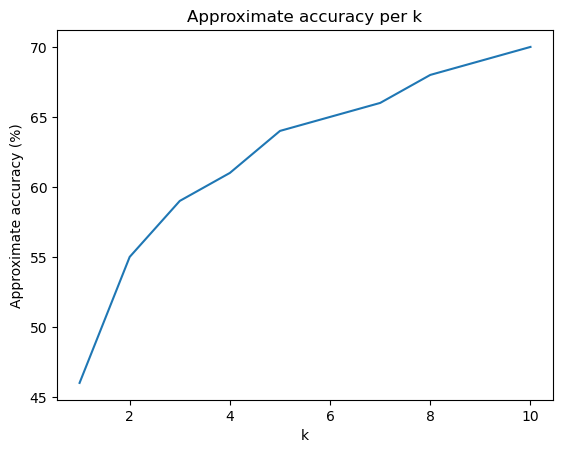

In [18]:
plt.plot(range(11)[1:], [46, 55, 59, 61, 64, 65, 66, 68, 69, 70])
plt.title("Approximate accuracy per k")
plt.xlabel("k")
plt.ylabel("Approximate accuracy (%)")
plt.show()

I will leave finding the optimal `k` to you. As this depends on the application. For example, in Google Translate a higher `k` could get you synonyms for words, but it could also spit out nonsense (although, it does so regardless in this current implementation).

However, purely by diminishing returns, one would not have much benefit going beyond a `k` of about `2` or `3`.

## Part II: Document Search

In this part of the assignment I will try to compare whole documents and look for similar ones.

### Step 1: Tweet cleaning

Just like in FA1 and FA2, I will just copy over the tweet cleaning functions.

In [19]:
def remove_substrings(s: str, substrings: list[str])-> str:
    """
    Remove a substrings from string.
    
    This function takes a list of substrings to remove and uses regex to remove them from the original string.
    This means the `substrings` parameter is completely regex compatible.

    :param s: (str) Original string to remove from.
    :param substrings: (list[str]) List of substrings to remove. May contain regex.

    :return: (str) String with all of the substrings removed.
    """
    for substring in substrings:
        s = re.sub(substring, '', s)
    return s
def remove_from_words(words: list[str], tokens: list[str]):
    """
    Remove tokens from list of words.
    
    This function takes a list of tokens to remove from list of words.

    :param words: (list[str]) List of words to remove from.
    :param tokens: (list[str]) list of tokens to remove. Not regex compatible.

    :return: (list[str]) List of all given `words` that are not in `tokens`.
    """
    return [word for word in words if word not in tokens]
tweet_tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
stemmer = PorterStemmer()

def clean_string(s: str)-> list[str]:
    """
    Clean a given string with the following steps:

    - Remove '#', "RT", @ mentions, and URLs from string.
    - Split string into list of tokens.
    - Remove punctuation tokens and stopwords
    - Return each word to its stem.
    - Return new (cleaned) list of words.

    :param s: (str) String to clean

    :return: (list[str]) List of cleaned words
    """
    # Remove #, RT, @mention, and URL.
    s = remove_substrings(
            s, 
            [
                '#',
                "RT",
                r"https?://[^\s\n\r]+",
                r"(\s@[A-Za-z0-9_]+)"
            ]
        )

    # Tokenize the string.
    tokens = tweet_tokenizer.tokenize(s)

    # Remove punctuation and stopwords.
    tokens = remove_from_words(tokens, list(string.punctuation) + stopwords.words('english'))

    # Make word stems from tokens and return.
    return [stemmer.stem(token) for token in tokens]

def create_frequency_dict(tweets: list[tuple[list[str], bool]])-> dict[tuple[str, bool], int]:
    """
    Create frequency dictionary for each word in each tweet.

    This function takes a list of tweets and counts each word (positive and negative) and outputs it in a dictionary of the following format:
    ```py
    {
        (word, sentiment) : frequency
    }
    ```
    So for example:
    ```py
    {
        (happi, 1) : 50, 
        (happi, 0) : 10
    } 
    ```

    :param tweets: (list[tuple[list[str], bool]]) List of tweets. Each tweet is a tuple of a list of words, and a boolean representing the sentiment (1 = positive).

    :return: (dict[tuple[str, bool], int]) Dictionary with in the key the word and the sentiment, and in the frequency as value.
    """
    frequency_dict = {}
    for tweet in tweets:
        for word in tweet[0]:
            try:
                frequency_dict[(word, tweet[1])] += 1
            except KeyError:
                frequency_dict[(word, tweet[1])] = 1
    return frequency_dict
def create_frequency_list(frequency_dict: dict[tuple[str, bool], int])-> list[tuple[str, int, int]]:
    words_for_index = list(set([word for word, _ in frequency_dict.keys()]))
    frequency_list = [['', 0, 0] for _ in range(len(words_for_index))] # doesnt work with `[['', 0, 0]] * len(words_for_index)`, as this copies the sublist to each index by reference...
    
    for (word, sentiment), frequency in frequency_dict.items():
        i = words_for_index.index(word)
        frequency_list[i][0] = (word)
        frequency_list[i][2-sentiment] = frequency

    return frequency_list

### Step 2: Loading data

I do not really care about the semantics of a tweet, so Lets just combine both into a total.

In [20]:
tweets = twitter_samples.strings("positive_tweets.json") + twitter_samples.strings("negative_tweets.json")

tweets[:5]

['#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)',
 '@Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!',
 '@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!',
 '@97sides CONGRATS :)',
 'yeaaaah yippppy!!!  my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days']

### Step 3: Cleaning tweets

Now lets clean all the tweets.

In [21]:
clean_tweets = [clean_string(tweet) for tweet in tweets]

clean_tweets[:2]

[['followfriday', 'top', 'engag', 'member', 'commun', 'week', ':)'],
 ['hey',
  'jame',
  'odd',
  ':/',
  'pleas',
  'call',
  'contact',
  'centr',
  '02392441234',
  'abl',
  'assist',
  ':)',
  'mani',
  'thank']]

### Step 4: Cleaning the embeddings

Seeing as we brought back the tweets to its stems and the embeddings we have are not, we will need to clean the words in the embeddings as if it were tweets, in order to make the dictionary searchable again.

In [22]:
en_stem_embeddings = {stemmer.stem(word): embedding for word, embedding in en_embeddings.items()}

f"Before: {list(en_embeddings.keys())[:5]},    after: {list(en_stem_embeddings.keys())[:5]}"

"Before: ['the', 'was', 'for', 'that', 'with'],    after: ['the', 'wa', 'for', 'that', 'with']"

### Step 5: Embed documents

Now we can write a function that embeds entire tweets into a single vector.

This can be done by simply summing up all embeddings for the words in the tweet. This also means that if a single word appears multiple times, it will weigh more into the resulting vector.

In [23]:
def embed_document(clean_tweet: list[str], english_embeddings: dict[str, np.ndarray])-> np.ndarray:
    """
    Embed a given tweet.

    The embedding of an entire tweet is just the sum of its part. 
    So for each word, the embeddings will be added to a total.
    
    :param clean_tweet: (list[str]) cleaned version of a tweet, that consists of a list of stems
    :param english_embeddings: (dict[str, np.ndarray]) english embeddings that have stems for keys

    :return: (np.ndarray) sum of all available embeddings for the words in `clean_tweet`
    """
    embedded_document = np.zeros(len(list(english_embeddings.values())[0]))
    for word in clean_tweet:
        try:
            embedded_document += english_embeddings[word]
        except:
            # If the word is not im embeddings, skip the word. 
            # This is a skill issue on behalf of those who made this assignment.
            continue
    return embedded_document

In [24]:
first_embedded_tweet = embed_document(clean_tweets[1], en_stem_embeddings)
first_embedded_tweet

array([ 0.1126709 ,  0.39093018, -0.20835876,  0.91792297,  0.0637207 ,
       -0.16004944,  0.51046371, -0.53623962, -0.03210449,  0.17657471,
       -1.07324219, -1.07781982, -0.91320801, -0.06915283,  0.34828949,
        1.35241699,  1.68703651,  0.52368164, -0.3170166 , -0.70336914,
        1.30380249,  0.39350128,  1.29614258, -0.32333374, -0.08312988,
        0.04990387, -0.59069824,  0.06884766, -0.06835938, -0.96679688,
        1.14215088, -0.68395996, -0.12548828, -1.15014648,  0.4866333 ,
        0.0602417 ,  1.14501953,  0.28479004, -0.01319885,  0.81567383,
        1.34558105, -0.64929199,  0.79016113, -0.12564087,  0.41589355,
       -1.05401611, -0.10742188, -0.16870117, -0.03857422, -0.79719543,
       -0.81030273, -0.00628662,  0.5201416 ,  0.99804688, -0.11495972,
        0.64620972,  0.16507721, -0.16943359,  0.38897705, -0.72079468,
       -0.39172363,  0.95507812, -1.21133423, -0.14355469, -0.24565125,
       -0.48034668, -1.08129883, -0.07141113, -0.25904846,  1.30

### Step 6: Local Sensitive Hashing

Now we can start to make local sensitive hashing.

During deliberations with Brian, I came to a bucket size of about 10 to 20. For now I will keep this at 10, to optimize performance. If its fast and correct enough, I will not need to change this.

First off, I will make a hashing function that will hash any vector based on the given planes.

In [25]:
def hash_vector(vector: np.ndarray, planes: np.ndarray)-> int:
    """
    Hash a vector using planes.T

    I yoinked this function from https://gitlab.com/hu-hbo-ict/ai/nlp-livecode/-/blob/main/lsh.ipynb
    I did alter it to include a np.sign(), as I saw that being used elsewhere.
    Also, I cast the hash to an integer, as * causes it to form floats.
    """
    s = np.sign(np.dot(vector, planes))
    h = np.squeeze(s >= 0)

    hash = 0
    for i in range(planes.shape[1]):
        hash += 2**i * h[i]
        
    return int(hash)

Now to make those planes. I will first need to know the exact dimensions of my tweets and their embeddings.

In [26]:
f"There are {len(clean_tweets)} tweets, and there are {len(list(en_embeddings.values())[0])} embeddings for each tweet."

'There are 10000 tweets, and there are 300 embeddings for each tweet.'

Okay, so now to figure out how many planes we need:
Each plane divides the data in two. So we will need `n` planes to divide the data into `2^n` buckets. 

Like stated before, we're looking for about 10 vectors per buckets, which means we need `1000` buckets. 

We can just put those against each other and solve for `n`.\
`2^n = 1000`\
`n = log2(1000)`\
`n ≈ 9.96`

For the sake of simplicity, lets say `n = 10`. This means we will need 10 planes.

So lets make them!

In [27]:
planes = np.random.normal(size=(300, 10))
f"{planes.shape = }"

'planes.shape = (300, 10)'

Cool, now lets try to hash the first tweet!

In [28]:
hash_vector(first_embedded_tweet, planes)

338

Fancy!

### Step 7: Hash tables
Now that we have a unique number for each vector, we want to create a hash table, such that we can quickly look up any list of vectors, given that we have a hash. For this, I will just use Bribri's `make_hash_table()` function. 

In [29]:
# Function yoinked from https://gitlab.com/hu-hbo-ict/ai/nlp-livecode/-/blob/main/lsh.ipynb
def make_hash_table(vecs, planes):
    num_buckets = 2**planes.shape[1]

    buckets = {index: [] for index in range(num_buckets)} # hash -> vec
    lookup = {index: [] for index in range(num_buckets)} # hash -> id

    for i, v in enumerate(vecs):
        h = hash_vector(v, planes)
        
        buckets[h].append(v)
        lookup[h].append(i)
        
    return buckets, lookup

Great, now we just embed all the tweets and put them through it.

In [30]:
embedded_tweets = [embed_document(clean_tweet, en_stem_embeddings) for clean_tweet in clean_tweets]
embedded_tweets[0]

array([ 0.20788574,  0.08044434,  0.05761719, -0.06884766, -0.29162598,
        0.02783203, -0.41986084, -1.53222656,  0.6953125 ,  0.06054688,
        0.31976318, -0.42797852, -0.06222534,  0.5793457 , -0.22949219,
        0.55371094,  0.36431885,  0.42382812, -0.8215332 ,  0.03515625,
        0.03723145,  0.0859375 , -0.34182739,  0.10540771,  0.05358887,
       -0.11474609, -0.31982422,  0.08837891,  0.34082031, -0.09561157,
       -0.33068848, -0.27624512,  0.21282959,  0.21044922,  0.44042969,
       -0.47625732,  0.29760742, -0.20166016, -0.44873047, -0.13049316,
        0.04455566,  0.12508392, -0.47009277, -0.11376953,  0.52734375,
       -0.25158691, -0.25976562, -0.72958374,  0.16320801,  0.30773926,
       -0.17944336, -0.29846191, -0.40306091,  0.39880371, -0.49731445,
        0.07829285, -0.40881348, -0.42944336, -0.01025391, -0.49176025,
       -0.02133179,  0.37548828, -0.02154541,  0.09643555, -0.25866699,
        0.18310547,  0.17749023,  0.58636475,  0.19042969,  0.71

In [31]:
buckets, lookup = make_hash_table(embedded_tweets, planes)
f"Length of buckets: {len(buckets.keys())}. Length of lookup: {len(lookup.keys())}."

'Length of buckets: 1024. Length of lookup: 1024.'

And would you look at that. 1024 perfectly good buckets!

### Step 8: Actually finding similar tweets

Now that we have the hashes, lets try to find all the similar tweets for the first tweet.

To do this, I made a function that implements Bribri's code again.

In [32]:
def find_k_similar_tweets(embedded_tweet: np.ndarray, buckets: dict[int, list[np.ndarray]], lookup: dict[int, list[int]], tweets: list[str], k: int)-> list[tuple[str, float]]:
    """
    Find k similar tweets, based on `buckets` and `lookup`, to `clean_tweet`.
    If less than `k` similar tweets are present, return all from bucket.

    :param embedded_tweet: embedded document for entire tweet to find similar tweets for
    :param buckets: (dict[int, list[np.ndarray]]) hash table with for each hash a list of document embeddings
    :param lookup: (dict[int, list[int]]) hash table with for each hash, a list of ids
    :param tweets: (list[str]) all uncleaned tweets
    :param k: (int) the `k` similar tweets will be returned

    :return: (list[tuple[str, float]]) for the `k` most similar tweets, return the tweet and cosine similarity.

    """
    res = []
    tweet_hash = hash_vector(embedded_tweet, planes)

    similars = []
    for h, v in zip(buckets[tweet_hash], lookup[tweet_hash]):
        similars.append((cosine_similarity(h, first_embedded_tweet.squeeze()), h, v))


    similars.sort(key = itemgetter(0), reverse=True)

    for c, _, v in similars[:k]:
        res.append((tweets[v], c))
    
    return res


Lets try it for the first tweet:

In [33]:
first_tweet_hash = hash_vector(first_embedded_tweet, planes)

print(f"First tweet:\n{tweets[0]}.\nHash: {first_tweet_hash}. Bucket size: {len(buckets[first_tweet_hash])}\n\n")

for tweet, c in find_k_similar_tweets(first_embedded_tweet, buckets, lookup, tweets, 4):
    print(f"Tweet:  {tweet}.\nCosine similarity:  {c}.\n")

First tweet:
#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :).
Hash: 338. Bucket size: 204


Tweet:  @Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!.
Cosine similarity:  1.0.

Tweet:  @jamestheeight Hey James, thanks for the tweet. Not currently, no :). Let us know if we can help with anything else. -AL.
Cosine similarity:  0.793872964691253.

Tweet:  James_Yammouni Hey JAMES! Thanks for the follow but PLEASE follow ✧｡ Chelny ｡✧ :).
Cosine similarity:  0.7346632321522166.

Tweet:  @WeeklyChris 

Please tweet me something I'm sad :( you can cheer me up 
please...
Cosine similarity:  0.7180320111406081.



Damn, pretty cool! I do not really know myself which tweets should be closest, but it does not seem all that wrong? Honestly, I do not really know if there is a right answer, as the assignment does not have any testcases or examples that can help me with this.

Anyway, I did not care much for the assignment, sadly. Too bad, so sad, I hope FA5 is better.